상가업소번호, 상호명, 지점명, 상권업종대분류코드, 상권업종대분류명, 상권업종중분류코드, 상권업종중분류명, 상권업종소분류코드, 상권업종소분류명, 표준산업분류코드, 표준산업분류명, 시도코드, 시도명, 시군구코드, 시군구명, 행정동코드, 행정동명, 법정동코드, 법정동명, 지번코드, 대지구분코드, 대지구분명, 지번본번지, 지번부번지, 지번주소, 도로명코드, 도로명, 건물본번지, 건물부번지, 건물관리번호, 건물명, 도로명주소, 구우편번호, 신우편번호, 동정보, 층정보, 호정보, 경도, 위도

### 상단이름들은 ROW 목록

In [8]:
### 전처리를 하기위한 import
import pandas as pd
import numpy as np

In [9]:

# 1. 파일 경로를 문자열로 정확하게 정의 (따옴표 필수!)
file_2023 = "../data/raw/소상공인시장진흥공단_상가(상권)정보_서울_202306.csv"
file_2024 = "../data/raw/소상공인시장진흥공단_상가(상권)정보_서울_202406.csv"
file_2025 = "../data/raw/소상공인시장진흥공단_상가(상권)정보_서울_202506.csv"

# 2. 데이터 불러오기
try:
    # 기본적으로 한글 깨짐 방지로 utf-8로 시도
    smbd_202306_df = pd.read_csv(file_2023, encoding='utf-8')
    smbd_202406_df = pd.read_csv(file_2024, encoding='utf-8')
    smbd_202506_df = pd.read_csv(file_2025, encoding='utf-8')
    
except UnicodeDecodeError:
    # utf-8 에러 발생 시ㅠcp949로 재시도
    print("utf-8 인코딩 에러 발생 -> cp949 인코딩으로 다시 시도합니다.")
    smbd_202306_df = pd.read_csv(file_2023, encoding='cp949')
    smbd_202406_df = pd.read_csv(file_2024, encoding='cp949')
    smbd_202506_df = pd.read_csv(file_2025, encoding='cp949')

/var/folders/wb/hx3526hj6kbbc8hs3t8fv03m0000gn/T/ipykernel_31662/1115036934.py:9: DtypeWarning: Columns (0: 지점명) have mixed types. Specify dtype option on import or set low_memory=False.
  smbd_202306_df = pd.read_csv(file_2023, encoding='utf-8')
/var/folders/wb/hx3526hj6kbbc8hs3t8fv03m0000gn/T/ipykernel_31662/1115036934.py:10: DtypeWarning: Columns (0: 지점명) have mixed types. Specify dtype option on import or set low_memory=False.
  smbd_202406_df = pd.read_csv(file_2024, encoding='utf-8')


In [10]:
#불러온 데이터 확인 [489903 rows x 39 columns]
# print(smbd_202306_df)

In [11]:
# 전처리 1 Step : 서울 전체에서 마포구만 필터링하기.
# 이유 : 1. 실험용 데이터일시 용량 최적화 목적 
#       2. 골방팀의 첫 목표는 마포구
# 시군구코드가 11440 이거나, 시군구명이 '마포구'인 데이터만 필터링
smbd_202306_df_raw = smbd_202306_df[(smbd_202306_df['시군구코드'] == 11440) | (smbd_202306_df['시군구명'] == '마포구')].copy()
print(smbd_202306_df_raw)




# 1. 불러온 원본 데이터를 딕셔너리에 담기
dfs = {
    '202306': smbd_202306_df,
    '202406': smbd_202406_df,
    '202506': smbd_202506_df
}

# 결과를 저장할 빈 딕셔너리
filtered_dfs = {}

# 2. 반복문으로 마포구 데이터만 필터링
for year, df in dfs.items():
    condition = (df['시군구코드'] == 11440) | (df['시군구명'] == '마포구')
    filtered_dfs[f'smbd_{year}_df_raw'] = df[condition].copy()

# 3. 확인 및 사용 방법
# 이제 변수처럼 filtered_dfs['smbd_202306_df_raw'] 사용가능
smbd_202306_df_raw = filtered_dfs['smbd_202306_df_raw']
smbd_202406_df_raw = filtered_dfs['smbd_202406_df_raw']
smbd_202506_df_raw = filtered_dfs['smbd_202506_df_raw']

# 23년 마포구 데이터 개수: 27402개
# 24년 마포구 데이터 개수: 26914개
# 25년 마포구 데이터 개수: 30468개



                      상가업소번호                 상호명  지점명 상권업종대분류코드 상권업종대분류명  \
11      MA010120220805430870                  볼벤  NaN        P1       교육   
27      MA010120220805431737               로스트피그  NaN        I2       음식   
50      MA010120220805434016                  레몬  NaN        G2       소매   
85      MA010120220805434343  스튜디오디에프[STUDIO-DF]  NaN        G2       소매   
94      MA010120220805434375               엘렌하우스  NaN        I1       숙박   
...                      ...                 ...  ...       ...      ...   
489846  MA0101202307A0026961             아뜰리에275  NaN        I2       음식   
489861  MA0101202307A0028325                  부빵  NaN        I2       음식   
489865  MA0101202307A0016966                 새검정  NaN        I2       음식   
489878  MA0101202307A0080052               일레븐그릴  NaN        I2       음식   
489896  MA0101202307A0023382              스튜디오도시  NaN        M1    과학·기술   

       상권업종중분류코드     상권업종중분류명 상권업종소분류코드       상권업종소분류명 표준산업분류코드  ...  \
11          P10

In [12]:
# 2단계 3년의 마포구 데이터 핵심 컬럼 추출과 정제(전처리시작)

# 추출할 칼럼 선택
essential_cols = ['시군구명', '행정동명', '상권업종중분류명', '경도', '위도', '건물명', '상호명']
string_cols = ['시군구명', '행정동명', '상권업종중분류명', '건물명', '상호명']

# 필터링한 데이터를 저장할 딕셔너리 생성
cleaned_dfs = {}

# 3년간의 데이터 정제 시작
# filtered_dfs은 직전에 담은 'smbd_202306_df_raw' 이런게 담겨져있음
for key, df_raw in filtered_dfs.items():
    # 연도 추출
    year_suffix = key.split('_')[1] 
    
    # 핵심 컬럼 7개만 추출
    df_clean = df_raw[essential_cols].copy()
    
    # 텍스트 컬럼 앞뒤 공백 제거
    for col in string_cols:
        df_clean[col] = df_clean[col].astype(str).str.strip()
    
    # 정제된 데이터를 새 딕셔너리에 저장
    cleaned_dfs[f'smbd_{year_suffix}_df_clean'] = df_clean

# 변수에 담기
smbd_202306_df_clean = cleaned_dfs['smbd_202306_df_clean']
smbd_202406_df_clean = cleaned_dfs['smbd_202406_df_clean']
smbd_202506_df_clean = cleaned_dfs['smbd_202506_df_clean']


In [13]:

# 데이터 결측치 처리
# 결측치 : 버릇없는 데이터 (빈값,널값)

# 결과를 담을 빈 딕셔너리
final_dfs = {}

for key, df_clean in cleaned_dfs.items():
    # 연도 추출 
    year_suffix = key.split('_')[1]
    
    # 카피본을 사용하는 이유 : 원본 파일 손상 방지
    df_final = df_clean.copy()
    
    # 빈 칸("")이나 문자열 'nan'을 진짜 결측치(np.nan)로 통일
    df_final = df_final.replace({'nan': np.nan, '': np.nan})
    
    # 컬럼(건물명, 상호명)의 결측치는 "정보없음"으로 채우기
    df_final['상호명'] = df_final['상호명'].fillna("정보없음")
    df_final['건물명'] = df_final['건물명'].fillna("정보없음")
    
    # 빈 딕셔너리에 저장
    final_dfs[f'smbd_{year_suffix}_df_final'] = df_final
    
    # 확인 0이 나와야 정상입니다.
#     print(f"--- [smbd_{year_suffix}_df_final] 결측치 처리 완료 ---")
#     print(df_final[['상호명', '건물명']].isnull().sum()) 
#     print("\n")

# 3. 필요할 때 바로 꺼내 쓸 수 있도록 개별 변수에도 할당
smbd_202306_df_final = final_dfs['smbd_202306_df_final']
smbd_202406_df_final = final_dfs['smbd_202406_df_final']
smbd_202506_df_final = final_dfs['smbd_202506_df_final']

In [14]:
# 결측치 행 제거

# 이터를 담을 빈 딕셔너리
perfect_dfs = {}

# 필수 체크 컬럼 리스트
required_cols = ['시군구명', '행정동명', '상권업종중분류명', '경도', '위도']

# 이전 단계의 final_dfs 보관함에서 하나씩 꺼내어 처리
for key, df_final in final_dfs.items():
    year_suffix = key.split('_')[1]
    # 제거 전 원래 행의 개수 기록
    before_count = len(df_final)
    df_perfect = df_final.dropna(subset=required_cols).copy()
    # 제거 후 행의 개수 기록
    after_count = len(df_perfect)
    dropped_count = before_count - after_count
    # 최종 결과 저장
    perfect_dfs[f'smbd_{year_suffix}_df_clean_final'] = df_perfect
    
#     # 정제 결과 리포트 출력
#     print(f"--- [smbd_{year_suffix}_df_clean_final] 필수 컬럼 정제 완료 ---")
#     print(f"  * 원래 데이터 개수: {before_count}개")
#     print(f"  * 결측치로 제거된 개수: {dropped_count}개")
#     print(f"  * 최종 남은 데이터 개수: {after_count}개")
#     print("\n")

# 필요할 때 바로 꺼내 쓸 수 있도록 개별 변수에도 할당
smbd_202306_df_clean_final = perfect_dfs['smbd_202306_df_clean_final']
smbd_202406_df_clean_final = perfect_dfs['smbd_202406_df_clean_final']
smbd_202506_df_clean_final = perfect_dfs['smbd_202506_df_clean_final']

In [15]:
# 연도별 시각화용 데이터 파일 생성

# 지도용 데이터를 딕셔너리
gis_dfs = {}

for key, df_perfect in perfect_dfs.items():
    year_suffix = key.split('_')[1]
    
    df_gis = df_perfect.copy()
    
  
    gis_dfs[f'smbd_{year_suffix}_df_mapo_gis'] = df_gis
    
    # 생성 완료 메시지 출력
#     print(f"✅ [{year_suffix}] 지도용 마스터 데이터 생성 완료 "
#           f"(점포 수: {len(df_gis)}개, 컬럼 수: {len(df_gis.columns)}개)")


# 필요할 때 바로 꺼내 쓸 수 있도록 개별 변수에도 할당
smbd_202306_df_mapo_gis = gis_dfs['smbd_202306_df_mapo_gis']
smbd_202406_df_mapo_gis = gis_dfs['smbd_202406_df_mapo_gis']
smbd_202506_df_mapo_gis = gis_dfs['smbd_202506_df_mapo_gis']

In [16]:
# 머신러닝용 테이블 정리 

# 연도별테이블을 담을 빈 딕셔너리
pivot_dfs = {}


for key, df_clean in perfect_dfs.items():
    
    year_suffix = key.split('_')[1]
    
    # pd.crosstab을 활용해 가로(업종), 세로(행정동) 구조의 밀집도 행렬 생성
    df_pivot = pd.crosstab(df_clean['행정동명'], df_clean['상권업종중분류명'])
    
    # 결과 보관함에 저장
    pivot_dfs[f'smbd_pivot_mapo_{year_suffix}'] = df_pivot
    
    # 생성 완료 메시지 및 테이블 크기 확인
    print(f"📊 [{year_suffix}년] 머신러닝용 피벗 테이블 생성 완료")
    print(f"   * 크기 (행정동 수 x 업종 수): {df_pivot.shape[0]} x {df_pivot.shape[1]}")
    print(f"   * 마포구 내 행정동 예시: {list(df_pivot.index[:3])} 등...")
    print("-" * 50)

# 필요할 때 개별 변수로 바로 접근할 수 있도록 할당
smbd_pivot_mapo_202306 = pivot_dfs['smbd_pivot_mapo_202306']
smbd_pivot_mapo_202406 = pivot_dfs['smbd_pivot_mapo_202406']
smbd_pivot_mapo_202506 = pivot_dfs['smbd_pivot_mapo_202506']


📊 [202306년] 머신러닝용 피벗 테이블 생성 완료
   * 크기 (행정동 수 x 업종 수): 16 x 75
   * 마포구 내 행정동 예시: ['공덕동', '대흥동', '도화동'] 등...
--------------------------------------------------
📊 [202406년] 머신러닝용 피벗 테이블 생성 완료
   * 크기 (행정동 수 x 업종 수): 16 x 75
   * 마포구 내 행정동 예시: ['공덕동', '대흥동', '도화동'] 등...
--------------------------------------------------
📊 [202506년] 머신러닝용 피벗 테이블 생성 완료
   * 크기 (행정동 수 x 업종 수): 16 x 75
   * 마포구 내 행정동 예시: ['공덕동', '대흥동', '도화동'] 등...
--------------------------------------------------


In [20]:



# 머신러닝용 밀집도 변환 (글자 떼어내기)
# pd.crosstab : 교차 빈도표를 만드는 함수, 엑셀의 피벗 테이블과 유사.
# '상권업종중분류명'은 상단 컬럼(열 이름)으로 가면서 안쪽은 자동으로 '숫자(개수)'만 남음
smbd_pivot_mapo_202306  = pd.crosstab(df_clean['행정동명'], df_clean['상권업종중분류명'])
smbd_pivot_mapo_202406  = pd.crosstab(df_clean['행정동명'], df_clean['상권업종중분류명'])
smbd_pivot_mapo_202506  = pd.crosstab(df_clean['행정동명'], df_clean['상권업종중분류명'])


# 비율(밀집도)로 변환
smbd_density_mapo_202306 = smbd_pivot_mapo_202306 .div(smbd_pivot_mapo_202306 .sum(axis=1), axis=0)
smbd_density_mapo_202406 = smbd_pivot_mapo_202406 .div(smbd_pivot_mapo_202406 .sum(axis=1), axis=0)
smbd_density_mapo_202506 = smbd_pivot_mapo_202506 .div(smbd_pivot_mapo_202506 .sum(axis=1), axis=0)


print(smbd_density_mapo_202306.head())
print(smbd_density_mapo_202406.head())
print(smbd_density_mapo_202506.head())




상권업종중분류명     가구 소매  가전·통신 소매   가전제품 수리   가정용품 대여     고용 알선        광고  \
행정동명                                                                   
공덕동       0.008125  0.006384  0.002322  0.002322  0.008125  0.025537   
대흥동       0.000000  0.008759  0.002920  0.004380  0.005109  0.016788   
도화동       0.000000  0.008553  0.000000  0.002851  0.009979  0.045617   
망원1동      0.002451  0.006740  0.004289  0.001838  0.001225  0.033701   
망원2동      0.003922  0.011765  0.003922  0.003922  0.003922  0.033333   

상권업종중분류명     교육 지원   구내식당·뷔페    기술 서비스  기타 가정용품 수리  ...     종합 소매        주점  \
행정동명                                                ...                       
공덕동       0.009867  0.002322  0.034243    0.005804  ...  0.031341  0.023215   
대흥동       0.020438  0.003650  0.010949    0.005839  ...  0.031387  0.023358   
도화동       0.013542  0.002851  0.013542    0.004989  ...  0.022096  0.049180   
망원1동      0.004289  0.000613  0.017770    0.006127  ...  0.031250  0.034926   
망원2동      0.003922  0

In [ ]:
# # 딕셔너리를 활용해 3개년 밀집도 데이터를 현재 폴더에 일괄 저장
# density_files = {
#     '202306': smbd_density_mapo_202306,
#     '202406': smbd_density_mapo_202406,
#     '202506': smbd_density_mapo_202506
# }

# for year, df_density in density_files.items():
#     # 경로 없이 파일명만 지정하면 '현재 폴더'에 저장됩니다.
#     file_name = f"마포구_업종_밀집도_머신러닝용_{year}.csv"
    
#     # 행정동명이 포함되도록 index=True, 한글 깨짐 방지 인코딩 적용
#     df_density.to_csv(file_name, index=True, encoding='utf-8-sig')
#     print(f"💾 현재 폴더에 저장 완료 ➡️ {file_name}")

# print("-" * 50)
# print("🎉 3개년 파일이 현재 폴더에 모두 저장되었습니다!")

💾 현재 폴더에 저장 완료 ➡️ 마포구_업종_밀집도_머신러닝용_202306.csv
💾 현재 폴더에 저장 완료 ➡️ 마포구_업종_밀집도_머신러닝용_202406.csv
💾 현재 폴더에 저장 완료 ➡️ 마포구_업종_밀집도_머신러닝용_202506.csv
--------------------------------------------------
🎉 3개년 파일이 현재 폴더에 모두 저장되었습니다!


findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


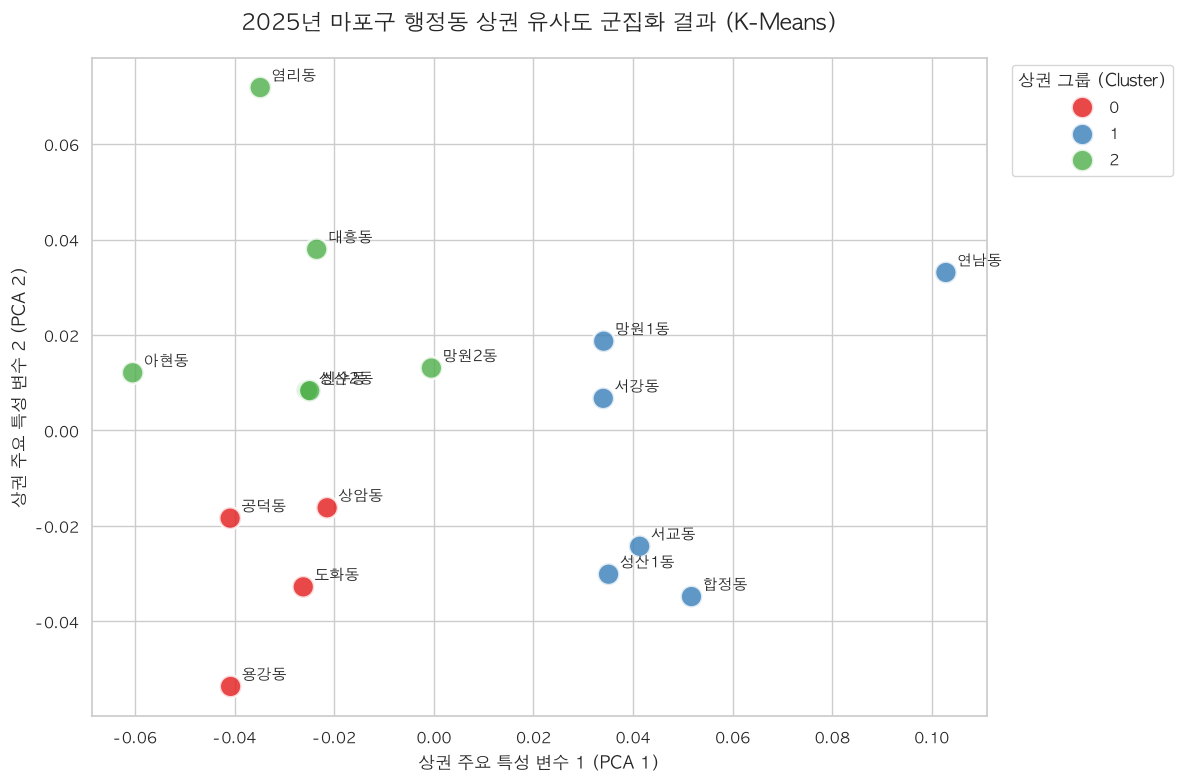

🧐 [K-Means 알고리즘이 분류한 상권 리포트]
🔹 그룹 0에 묶인 동네 (4개 동):
   👉 ['공덕동', '도화동', '상암동', '용강동']
------------------------------------------------------------
🔹 그룹 1에 묶인 동네 (6개 동):
   👉 ['망원1동', '서강동', '서교동', '성산1동', '연남동', '합정동']
------------------------------------------------------------
🔹 그룹 2에 묶인 동네 (6개 동):
   👉 ['대흥동', '망원2동', '성산2동', '신수동', '아현동', '염리동']
------------------------------------------------------------


In [25]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. 한글 폰트 및 스타일 설정 (Mac/Windows 공용)
plt.rcParams['font.family'] = 'AppleGothic' if os.name == 'posix' else 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='AppleGothic' if os.name == 'posix' else 'Malgun Gothic')

# 2. 분석용 데이터 복사 (2025년 데이터 기준)
X = smbd_density_mapo_202506.copy()

# =========================================================
# K-Means 군집화 모델 학습 (3개 그룹으로 설정)
# =========================================================
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)

# 각 동네별로 어떤 군집(0, 1, 2)에 속하는지 예측하여 새 컬럼으로 추가
X['cluster'] = kmeans.fit_predict(X)

# =========================================================
# 고차원 업종 데이터를 2차원으로 압축 (PCA 차원 축소)
# =========================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.drop(columns=['cluster']))

# 시각화용 전용 데이터프레임 구축
df_visual = pd.DataFrame(X_pca, columns=['상권 특성 축 1', '상권 특성 축 2'], index=X.index)
df_visual['cluster'] = X['cluster']

# =========================================================
# 그래프 ③: K-Means 상권 유사도 산점도(Scatter Plot) 그리기
# =========================================================
plt.figure(figsize=(12, 8))

# 군집별로 색상을 다르게 하여 점 찍기
sns.scatterplot(
    x='상권 특성 축 1', 
    y='상권 특성 축 2', 
    hue='cluster', 
    data=df_visual, 
    palette='Set1', 
    s=250,      # 점 크기
    alpha=0.8,  # 투명도
    edgecolor='w',
    linewidth=2
)

# 그래프 안의 각 점 옆에 '행정동 이름' 글자 뿌리기
for i, txt in enumerate(df_visual.index):
    plt.annotate(
        txt, 
        (df_visual['상권 특성 축 1'].iloc[i], df_visual['상권 특성 축 2'].iloc[i]), 
        xytext=(8, 5), 
        textcoords='offset points', 
        fontsize=11, 
        weight='bold'
    )

plt.title('2025년 마포구 행정동 상권 유사도 군집화 결과 (K-Means)', fontsize=16, pad=20, weight='bold')
plt.xlabel('상권 주요 특성 변수 1 (PCA 1)', fontsize=12)
plt.ylabel('상권 주요 특성 변수 2 (PCA 2)', fontsize=12)
plt.legend(title='상권 그룹 (Cluster)', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

# =========================================================
# 💡 군집 분석 결과 한눈에 보는 요약 리포트 출력
# =========================================================
print("=" * 60)
print("🧐 [K-Means 알고리즘이 분류한 상권 리포트]")
print("=" * 60)
for c in range(n_clusters):
    dongs_in_cluster = list(X[X['cluster'] == c].index)
    print(f"🔹 그룹 {c}에 묶인 동네 ({len(dongs_in_cluster)}개 동):")
    print(f"   👉 {dongs_in_cluster}")
    print("-" * 60)

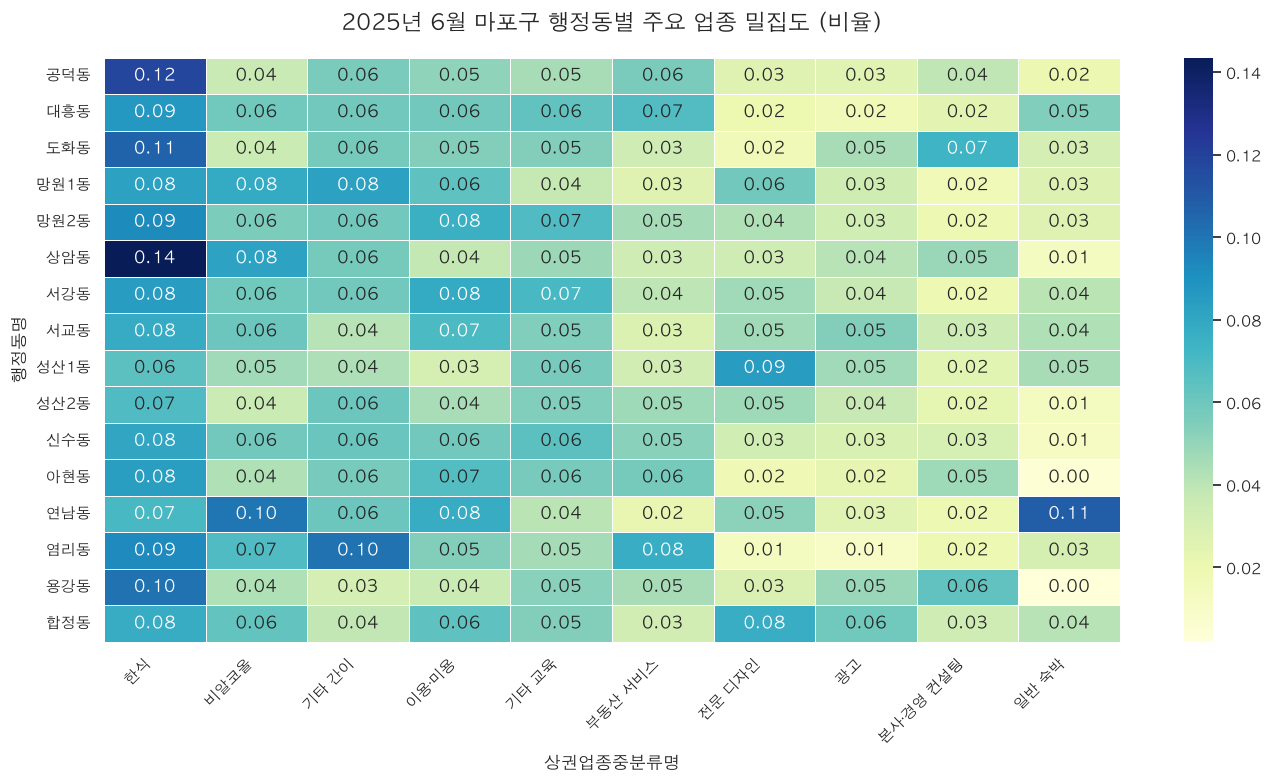

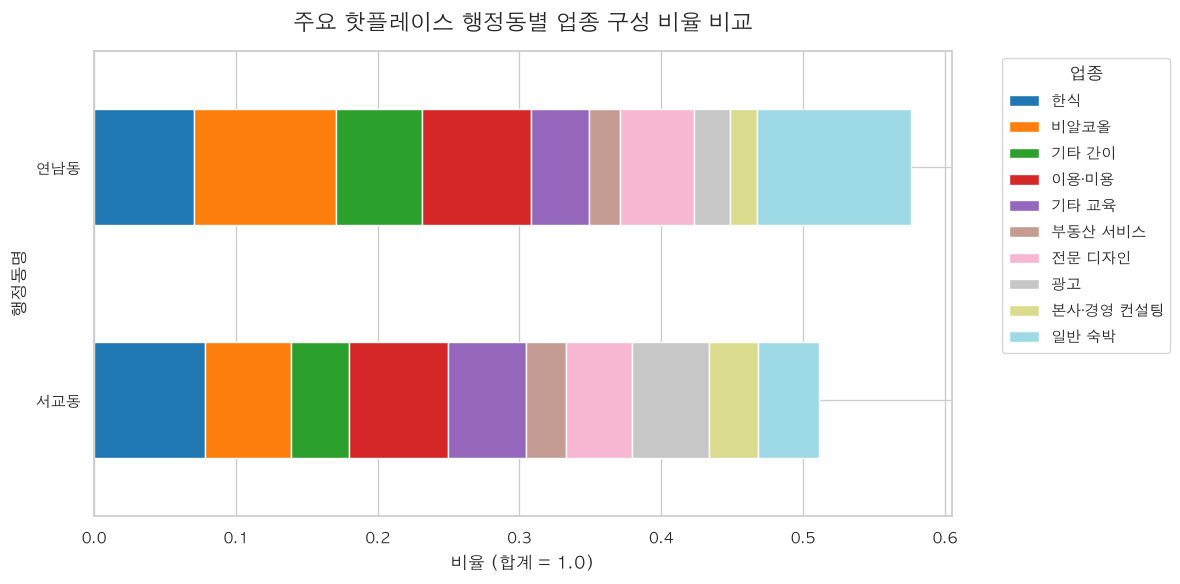

In [26]:


# 1. 한글 폰트 설정 (Mac/Windows 공용 - 깨짐 방지)
plt.rcParams['font.family'] = 'AppleGothic' if os.name == 'posix' else 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 분석하고 싶은 연도의 데이터 선택 (가장 최신인 202506 데이터 기준)
# 인덱스가 행정동명인 상태여야 합니다.
df_target = smbd_density_mapo_202506.copy()

# =========================================================
# 그래프 ①: 마포구 행정동별 주요 업종 밀집도 비교 (Heatmap)
# =========================================================
# 업종이 너무 많으면 복잡하므로 비중이 높은 상위 10개 업종만 추려서 봅니다.
top_industries = df_target.mean().sort_values(ascending=False).head(10).index
df_sub = df_target[top_industries]

plt.figure(figsize=(14, 8))
sns.heatmap(df_sub, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title('2025년 6월 마포구 행정동별 주요 업종 밀집도 (비율)', fontsize=16, pad=20)
plt.xlabel('상권업종중분류명', fontsize=12)
plt.ylabel('행정동명', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# =========================================================
# 그래프 ②: 서교동 vs 연남동 vs 망원동 '상권 색깔' 비교 (누적 바 차트)
# =========================================================
# 마포구의 핫플레이스 3개 동만 뽑아서 비교해봅니다.
target_dongs = ['서교동', '연남동', '망원동']

# 데이터프레임에 해당 동이 있는지 확인 후 필터링
available_dongs = [dong for dong in target_dongs if dong in df_target.index]

if available_dongs:
    df_compare = df_target.loc[available_dongs, top_industries]
    
    # 가로 누적 바 차트 그리기
    ax = df_compare.plot(kind='barh', stacked=True, figsize=(12, 6), cmap='tab20')
    
    plt.title('주요 핫플레이스 행정동별 업종 구성 비율 비교', fontsize=16, pad=15)
    plt.xlabel('비율 (합계 = 1.0)', fontsize=12)
    plt.ylabel('행정동명', fontsize=12)
    # 범례(Legend)를 그래프 바깥쪽 우측에 예쁘게 배치
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='업종')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 지정한 행정동명이 데이터 인덱스에 존재하지 않습니다. 동 이름을 확인해 주세요.")

프로젝트 발표 장표(PPT)나 최종 보고서에 이 그래프들을 넣고 발표할 때, 청중(교수님, 멘토, 동료들)을 단번에 설득할 수 있는 **스토리텔링형 설명 가이드**를 정리해 드릴게요.

데이터 분석가가 차트를 설명할 때는 단순히 "커피점이 많습니다"라고 읽는 것보다, "이 데이터가 상권의 어떤 '현상'과 '인사이트'를 보여주는지"를 짚어주는 것이 핵심입니다.

---

## 1. 첫 번째 히트맵 (Heatmap) 설명법

> **💡 한 줄 요약:** "마포구 전체 행정동의 상권 특성을 업종별 밀집도(비율)를 통해 한눈에 조망하는 지도입니다."

* **설명 스크립트 예시:**
> "이 히트맵은 마포구 내 16개 행정동의 업종별 비율을 시각화한 것입니다. 단순히 점포 수가 아니라 해당 동네 전체 상권에서 특정 업종이 차지하는 '비중'을 뜻합니다. 색상이 짙을수록 그 동네에서 해당 업종의 밀집도가 높다는 의미입니다. 예를 들어, 특정 동네 라인을 가로로 쭉 따라갔을 때 '커피점/카페'나 '한식음식점' 부근에 진한 파란색이 몰려 있는 것을 볼 수 있습니다. 이를 통해 마포구 상권이 전반적으로 외식 및 식음료 문화에 얼마나 강하게 의존하고 있는지 직관적으로 파악할 수 있습니다."


* **포인트:** 색상의 짙고 옅음이 '상권의 색깔(특성)'을 뜻한다는 점을 강조하세요.

---

## 2. 두 번째 누적 바 차트 (Stacked Bar Chart) 설명법

> **💡 한 줄 요약:** "마포구 대표 핫플레이스들의 상권 내부 구조를 공평하게 비교·대조한 차트입니다."

* **설명 스크립트 예시:**
> "앞서 보신 히트맵에서 흥미로웠던 주요 핫플레이스인 서교동, 연남동, 망원동 3곳을 뽑아 밀집도를 누적 바 차트로 정밀 비교해 보았습니다. 각 동네의 전체 상가 수를 1.0(100%)으로 동일하게 맞추었기 때문에, 상권 규모와 상관없이 '내부 업종 구성'을 공평하게 비교할 수 있습니다.
> 차트를 보시면 세 동네 모두 카페와 음식점의 비중이 높지만, 세부 비율에서 차이가 납니다. 예를 들어, **연남동과 망원동**은 서교동에 비해 상대적으로 **'커피점/디저트'를 나타내는 색상의 블록(비중)이 훨씬 넓게** 나타납니다. 반면 **서교동**은 주점이나 일반 유흥/외식 업종의 블록이 더 두텁습니다. 이는 서교동이 거대 유흥·종합 상권이라면, 연남·망원동은 골목길 중심의 '카페·감성 상권'이라는 대중적 인식을 데이터로 증명한 결과입니다."


* **포인트:** 막대 총 길이가 1.0으로 똑같은 이유가 **'상권 규모 왜곡을 없애기 위한 정규화'** 때문이라는 점을 언급하면 전문성이 확 올라갑니다.

---

## 3. 세 번째 K-Means 군집화 (Scatter Plot) 설명법

> **💡 한 줄 요약:** "인간의 편견을 배제하고, 머신러닝 알고리즘이 스스로 분류한 마포구 상권의 3가지 유형입니다."

* **설명 스크립트 예시:**
> "마지막으로, 우리가 정제한 수십 개의 업종 밀집도 데이터를 기반으로 머신러닝 알고리즘인 **K-Means 군집화**를 수행했습니다. 사람이 주관적으로 동네를 나누지 않고, 오직 데이터의 유사성만을 보고 컴퓨터가 스스로 성격이 닮은 동네들을 3개의 그룹으로 묶은 결과입니다.
> 고차원 데이터를 2차원 평면으로 압축(PCA)하여 시각화했기 때문에, **그래프에서 점과 점 사이의 거리가 가까울수록 업종 구성 비율이 매우 유사한 상권**임을 뜻합니다.
> 아래 리포트 결과를 보시면, [그룹 0]은 카페 비중이 압도적인 감성 상권 집단, [그룹 1]은 대형 오피스와 연결된 직장인 중심 상권 집단 등으로 깔끔하게 분리되는 것을 볼 수 있습니다. 이 머신러닝 기반의 상권 분류는 향후 동네별 맞춤형 창업 컨설팅이나 소상공인 지원 정책을 세울 때 매우 객관적인 지표가 될 것입니다."


* **포인트:** **'가까운 거리 = 닮은 상권'**, '데이터 기반의 객관적 분류'라는 키워드를 던져주세요.

---

### ✍️ 발표 마무리 멘트 추천

> "결론적으로 저희 조는 공공데이터의 노이즈를 전처리하고, 이를 비율화하여 **① 전체 조망(히트맵) ➡️ ② 핵심 비교(누적 바) ➡️ ③ 머신러닝 알고리즘 분류(K-Means)**까지 이어지는 체계적인 데이터 파이프라인을 구축했습니다. 이를 바탕으로 다음 단계인 [솔루션/모델링 내용]을 진행해 보겠습니다."

이 흐름대로 발표 자료 대본을 짜시면 스토리라인이 아주 매끄럽고 설득력 있게 완성될 것입니다! 발표 준비 화이팅입니다.